# Anomaly Detection — PatchCore

This notebook reimplements PatchCore to perform zero-shot anomaly detection on the competition dataset.

## Kaggle Dataset Structure

```
DATASET_ROOT/
├── class_1/
│   ├── train/
│   │   ├── good/                 # normal images
│   │   ├── <anomaly_type_1>/     # 5 anomalous images
│   │   ├── <anomaly_type_2>/     # 5 anomalous images
│   │   ├── <anomaly_type_3>/
│   │   ├── <anomaly_type_4>/
│   │   └── <anomaly_type_5>/
│   ├── ground_truth_train/       # masks for the 25 train anomalies
│   │   ├── <anomaly_type_1>/
│   │   ├── <anomaly_type_2>/
│   │   └── ...
│   └── test/                     # test images (NO ground truth)
├── class_2/
├── ...
└── anomaly_descriptions.csv              # textual descriptions per (class, anomaly)
```

## Notebook Structure

- First, the images in the dataset are loaded. 
- The PatchCore class with the algorithm logic is defined along with the hyperparameters choice.
- An instance of PatchCore is fit by building a memory bank using the normal images only.
- The performance of the PatchCore instance is validated by treating the ground truths of the anomalous images in the dataset as a validation set. 
- The trained PatchCore instance is used to generate anomaly maps for the test samples.
- Finally, the predicted anomaly maps are converted in the format required and stored in a submission file.

## 1. Setup

In [ ]:
!pip install -q timm scikit-learn pytorch-msssim tqdm

In [ ]:
import copy
import math
import os
import random
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset

import timm

In [38]:
# -------- Reproducibility ----------
SEED = 7

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# -------- Hardware ----------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = torch.cuda.is_available()
NUM_WORKERS = 2 if os.name != "nt" else 0
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


## 2. Configuration


In [39]:
# ---- Paths (edit me) ----
DATASET_ROOT = Path("/kaggle/input/datasets/piants/adl-challenge-anomaly-detection")           # root containing the 8 class folders
DESCRIPTIONS_CSV = Path("/kaggle/input/datasets/piants/adl-challenge-anomaly-detection/anomaly_descriptions.csv")  # CSV with textual descriptions

# ---- Folder-name conventions (edit if your dataset uses different names) ----
TRAIN_DIR_NAME = "train"
TEST_DIR_NAME = "test"
GT_TRAIN_DIR_NAME = "ground_truth_train"   # masks for the 5x5 train anomalies
GT_TEST_DIR_NAME = "ground_truth"          # OPTIONAL: masks for test anomalies
NORMAL_DIR_NAME = "good"                   # subfolder name for normal images

# ---- Image / training settings ----
IMAGE_SIZE = 224
VAL_RATIO = 0.15
N_VIS_SAMPLES = 5
BATCH_SIZE = 16

## 3. Discovering of the dataset structure

This step scans the dataset and prints what it finds. It is the cheapest way to
catch path/naming mistakes early. Also, inspecting the printed summary allows to find out whether a class is missing or anomaly counts look wrong.

In [ ]:
IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def list_image_files(folder):
    '''Returns all the files in a folder'''
    folder = Path(folder)
    if not folder.exists():
        return []
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS])

def discover_classes(root): 
    '''Returns a sorted list containing the names of the classes'''
    return sorted([d.name for d in Path(root).iterdir() if d.is_dir()]) 

def discover_class_structure(root, class_name):
    """Return a dict describing what is available for a single class."""
    cdir = Path(root) / class_name
    info = {"class": class_name, "train_normal": 0, "train_anomalies": {},
            "gt_train": {}, "test_subdirs": {}, "gt_test": {}, "test_flat": 0}

    info["train_normal"] = len(list_image_files(cdir / TRAIN_DIR_NAME / NORMAL_DIR_NAME))

    train_dir = cdir / TRAIN_DIR_NAME
    if train_dir.exists():
        for sub in sorted(train_dir.iterdir()):
            if sub.is_dir() and sub.name != NORMAL_DIR_NAME:
                info["train_anomalies"][sub.name] = len(list_image_files(sub))

    gt_train_dir = cdir / GT_TRAIN_DIR_NAME
    if gt_train_dir.exists():
        for sub in sorted(gt_train_dir.iterdir()):
            if sub.is_dir():
                info["gt_train"][sub.name] = len(list_image_files(sub))

    test_dir = cdir / TEST_DIR_NAME
    if test_dir.exists():
        flat_files = list_image_files(test_dir)
        info["test_flat"] = len(flat_files)
        for sub in sorted(test_dir.iterdir()):
            if sub.is_dir():
                info["test_subdirs"][sub.name] = len(list_image_files(sub))

    gt_test_dir = cdir / GT_TEST_DIR_NAME
    if gt_test_dir.exists():
        for sub in sorted(gt_test_dir.iterdir()):
            if sub.is_dir():
                info["gt_test"][sub.name] = len(list_image_files(sub))

    return info

if not DATASET_ROOT.exists():
    print(f"!! DATASET_ROOT not found: {DATASET_ROOT.resolve()}")
    print("   Edit the path in the configuration cell above.")
else:
    classes = discover_classes(DATASET_ROOT)
    print(f"Found {len(classes)} classes: {classes}\n")
    rows = []
    for cn in classes:
        info = discover_class_structure(DATASET_ROOT, cn)
        rows.append({
            "class": cn,
            "train_normal": info["train_normal"],
            "n_anomaly_types_train": len(info["train_anomalies"]),
            "train_anomaly_imgs_total": sum(info["train_anomalies"].values()),
            "gt_train_masks_total": sum(info["gt_train"].values()),
            "test_total": info["test_flat"] if info["test_flat"] > 0 else sum(info["test_subdirs"].values()),
            "test_organized_by_type": len(info["test_subdirs"]) > 0,
            "has_test_gt": len(info["gt_test"]) > 0,
        })
    summary_df = pd.DataFrame(rows)
    display(summary_df)

Found 8 classes: ['class_01', 'class_02', 'class_03', 'class_04', 'class_05', 'class_06', 'class_07', 'class_08']



,class,train_normal,n_anomaly_types_train,train_anomaly_imgs_total,gt_train_masks_total,test_total,test_organized_by_type,has_test_gt
0,class_01,2600,5,25,25,465,False,False
1,class_02,2135,6,30,30,800,False,False
2,class_03,2520,4,20,20,790,False,False
3,class_04,2585,5,25,25,745,False,False
4,class_05,2640,6,30,30,225,False,False
5,class_06,2335,7,35,35,1010,False,False
6,class_07,2145,7,35,35,915,False,False
7,class_08,2045,7,35,35,960,False,False


## 4. Loading of the textual descriptions

In [ ]:
CSV_CLASS_COL = "public_class"
CSV_ANOMALY_COL = "public_anomaly"
CSV_DESC_COL = "description"

descriptions_df = None
descriptions = {}  # (class_name, anomaly_type) -> description string

if DESCRIPTIONS_CSV.exists():
    descriptions_df = pd.read_csv(DESCRIPTIONS_CSV)
    print("CSV columns:", list(descriptions_df.columns))
    display(descriptions_df.head(10))

    if all(c in descriptions_df.columns for c in [CSV_CLASS_COL, CSV_ANOMALY_COL, CSV_DESC_COL]):
        for _, row in descriptions_df.iterrows():
            key = (str(row[CSV_CLASS_COL]).strip().lower(),
                   str(row[CSV_ANOMALY_COL]).strip().lower())
            descriptions[key] = str(row[CSV_DESC_COL])
        print(f"\nLoaded {len(descriptions)} descriptions.")
    else:
        print(f"\n!! Expected columns not all found.")
        print("   Edit CSV_CLASS_COL / CSV_ANOMALY_COL / CSV_DESC_COL above.")
else:
    print(f"!! CSV not found at {DESCRIPTIONS_CSV.resolve()}")

CSV columns: ['public_class', 'object_name', 'public_anomaly', 'description', 'example_image_relpath', 'example_mask_relpath']


,public_class,object_name,public_anomaly,description,example_image_relpath,example_mask_relpath
0,class_01,resistor,anomaly_01,Visual cue: same as standard color; irregular ...,class_01/train/anomaly_01/img_fc359284dc993a4f...,class_01/ground_truth_train/anomaly_01/img_fc3...
1,class_01,resistor,anomaly_02,Visual cue: same as standard color; depressed ...,class_01/train/anomaly_02/img_7287430a88dcd5fc...,class_01/ground_truth_train/anomaly_02/img_728...
2,class_01,resistor,anomaly_03,Localized visual anomaly affecting the object ...,class_01/train/anomaly_03/img_07c6a98a2b5ef6c3...,class_01/ground_truth_train/anomaly_03/img_07c...
3,class_01,resistor,anomaly_04,Visual cue: same as standard color; linear or ...,class_01/train/anomaly_04/img_6280d414abd8db5e...,class_01/ground_truth_train/anomaly_04/img_628...
4,class_01,resistor,anomaly_05,"Visual cue: same as standard color, may have d...",class_01/train/anomaly_05/img_85722831b9d36083...,class_01/ground_truth_train/anomaly_05/img_857...
5,class_02,inductor,anomaly_01,Visual cue: same as standard color; irregular ...,class_02/train/anomaly_01/img_ac774fb0858481e6...,class_02/ground_truth_train/anomaly_01/img_ac7...
6,class_02,inductor,anomaly_02,Localized visual anomaly affecting the object ...,class_02/train/anomaly_02/img_66fb96b52fa0ca6a...,class_02/ground_truth_train/anomaly_02/img_66f...
7,class_02,inductor,anomaly_03,Localized visual anomaly affecting the object ...,class_02/train/anomaly_03/img_d2758ef1155c7fa4...,class_02/ground_truth_train/anomaly_03/img_d27...
8,class_02,inductor,anomaly_04,Visual cue: same as standard block inductor co...,class_02/train/anomaly_04/img_5ff466eb47a27078...,class_02/ground_truth_train/anomaly_04/img_5ff...
9,class_02,inductor,anomaly_05,Visual cue: same as standard block color; line...,class_02/train/anomaly_05/img_42833ce682fa1f7b...,class_02/ground_truth_train/anomaly_05/img_428...



!! Expected columns not all found.
   Edit CSV_CLASS_COL / CSV_ANOMALY_COL / CSV_DESC_COL above.


## 5. Dataset class

`ProjectDataset` is a single `Dataset` class that knows about all four splits we
care about. Picking a split is just a string argument:

| split | content | label | mask |
|---|---|---|---|
| `train_normal` | only `train/good/` | 0 | zeros |
| `train_anomalous` | the anomaly images in `train/<type>/` for the current class | 1 | from `ground_truth_train/<type>/` |
| `train_all` | both of the above (useful for supervised methods) | 0 or 1 | as above |
| `test` | everything in `test/` (with GT masks if available, else zeros) | -1 | does not exist |

The `-1` label for test is because the test set has no GT, so we
can't say whether each image is normal or anomalous: we just store the image
and let the metric code skip those samples.

In [42]:
def pil_to_tensor(img):
    arr = np.asarray(img, dtype=np.float32)
    if arr.ndim == 2:
        arr = arr[..., None]
    arr = arr / 255.0
    return torch.from_numpy(arr).permute(2, 0, 1)


def find_mask_for_image(img_path, mask_dir):
    """Try several naming conventions to locate the mask for an image."""
    if mask_dir is None or not Path(mask_dir).exists():
        return None
    stem = Path(img_path).stem
    candidates = [
        f"{stem}_mask.png", f"{stem}_mask.jpg", f"{stem}_mask.bmp",
        f"{stem}.png",      f"{stem}.jpg",      f"{stem}.bmp",
    ]
    for c in candidates:
        p = Path(mask_dir) / c
        if p.exists():
            return p
    return None


class ProjectDataset(Dataset):
    """Single-class dataset adapted to the project structure.

    Supports the splits: train_normal, train_anomalous, train_all, test.
    """

    SPLITS = {"train_normal", "train_anomalous", "train_all", "test"}

    def __init__(self, root, class_name, split="train_normal", image_size=224):
        self.root = Path(root)
        self.class_name = class_name
        self.split = split
        self.image_size = image_size
        self.samples = []
        cdir = self.root / class_name

        if split not in self.SPLITS:
            raise ValueError(f"split must be one of {self.SPLITS}")

        if split in ("train_normal", "train_all"):
            for img_path in list_image_files(cdir / TRAIN_DIR_NAME / NORMAL_DIR_NAME):
                self.samples.append({
                    "image_path": img_path, "mask_path": None,
                    "label": 0, "defect_type": "good",
                })

        if split in ("train_anomalous", "train_all"):
            train_dir = cdir / TRAIN_DIR_NAME
            gt_train_dir = cdir / GT_TRAIN_DIR_NAME
            if train_dir.exists():
                for sub in sorted(train_dir.iterdir()):
                    if not sub.is_dir() or sub.name == NORMAL_DIR_NAME:
                        continue
                    defect_type = sub.name
                    mask_subdir = gt_train_dir / defect_type
                    for img_path in list_image_files(sub):
                        self.samples.append({
                            "image_path": img_path,
                            "mask_path": find_mask_for_image(img_path, mask_subdir),
                            "label": 1, "defect_type": defect_type,
                        })

        if split == "test":
            test_dir = cdir / TEST_DIR_NAME
            gt_test_dir = cdir / GT_TEST_DIR_NAME
            if not test_dir.exists():
                raise FileNotFoundError(f"Test folder not found: {test_dir}")

            subdirs = [s for s in sorted(test_dir.iterdir()) if s.is_dir()]
            if subdirs:
                # Case A: test/ is organized by defect type (MVTec convention)
                for sub in subdirs:
                    defect_type = sub.name
                    is_normal = defect_type.lower() in {"good", "normal", "ok"}
                    mask_subdir = gt_test_dir / defect_type if not is_normal else None
                    for img_path in list_image_files(sub):
                        self.samples.append({
                            "image_path": img_path,
                            "mask_path": find_mask_for_image(img_path, mask_subdir),
                            "label": 0 if is_normal else 1,
                            "defect_type": defect_type,
                        })
            else:
                # Case B: test/ is flat — likely no labels available
                for img_path in list_image_files(test_dir):
                    self.samples.append({
                        "image_path": img_path, "mask_path": None,
                        "label": -1, "defect_type": "unknown",
                    })

        if len(self.samples) == 0:
            raise RuntimeError(
                f"No samples for class={class_name!r}, split={split!r}"
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rec = self.samples[idx]
        image = Image.open(rec["image_path"]).convert("RGB")
        image = image.resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        image = pil_to_tensor(image)

        if rec["mask_path"] is None:
            mask = torch.zeros((1, self.image_size, self.image_size), dtype=torch.float32)
        else:
            m = Image.open(rec["mask_path"]).convert("L")
            m = m.resize((self.image_size, self.image_size), resample=Image.NEAREST)
            mask = (pil_to_tensor(m) > 0.5).float()

        return {
            "image": image,
            "mask": mask,
            "label": torch.tensor(rec["label"], dtype=torch.long),
            "defect_type": rec["defect_type"],
            "path": str(rec["image_path"]),
        }


def split_train_val(dataset, val_ratio=0.15, seed=SEED):
    n = len(dataset)
    idxs = np.arange(n)
    rng = np.random.default_rng(seed)
    rng.shuffle(idxs)
    n_val = max(1, int(round(n * val_ratio)))
    return Subset(dataset, idxs[n_val:].tolist()), Subset(dataset, idxs[:n_val].tolist())

## 6. Sanity check on one class

Visualization of a handful of normal training images, a few
anomalous training images with their GT masks, and a few test images.

Showing class: class_01


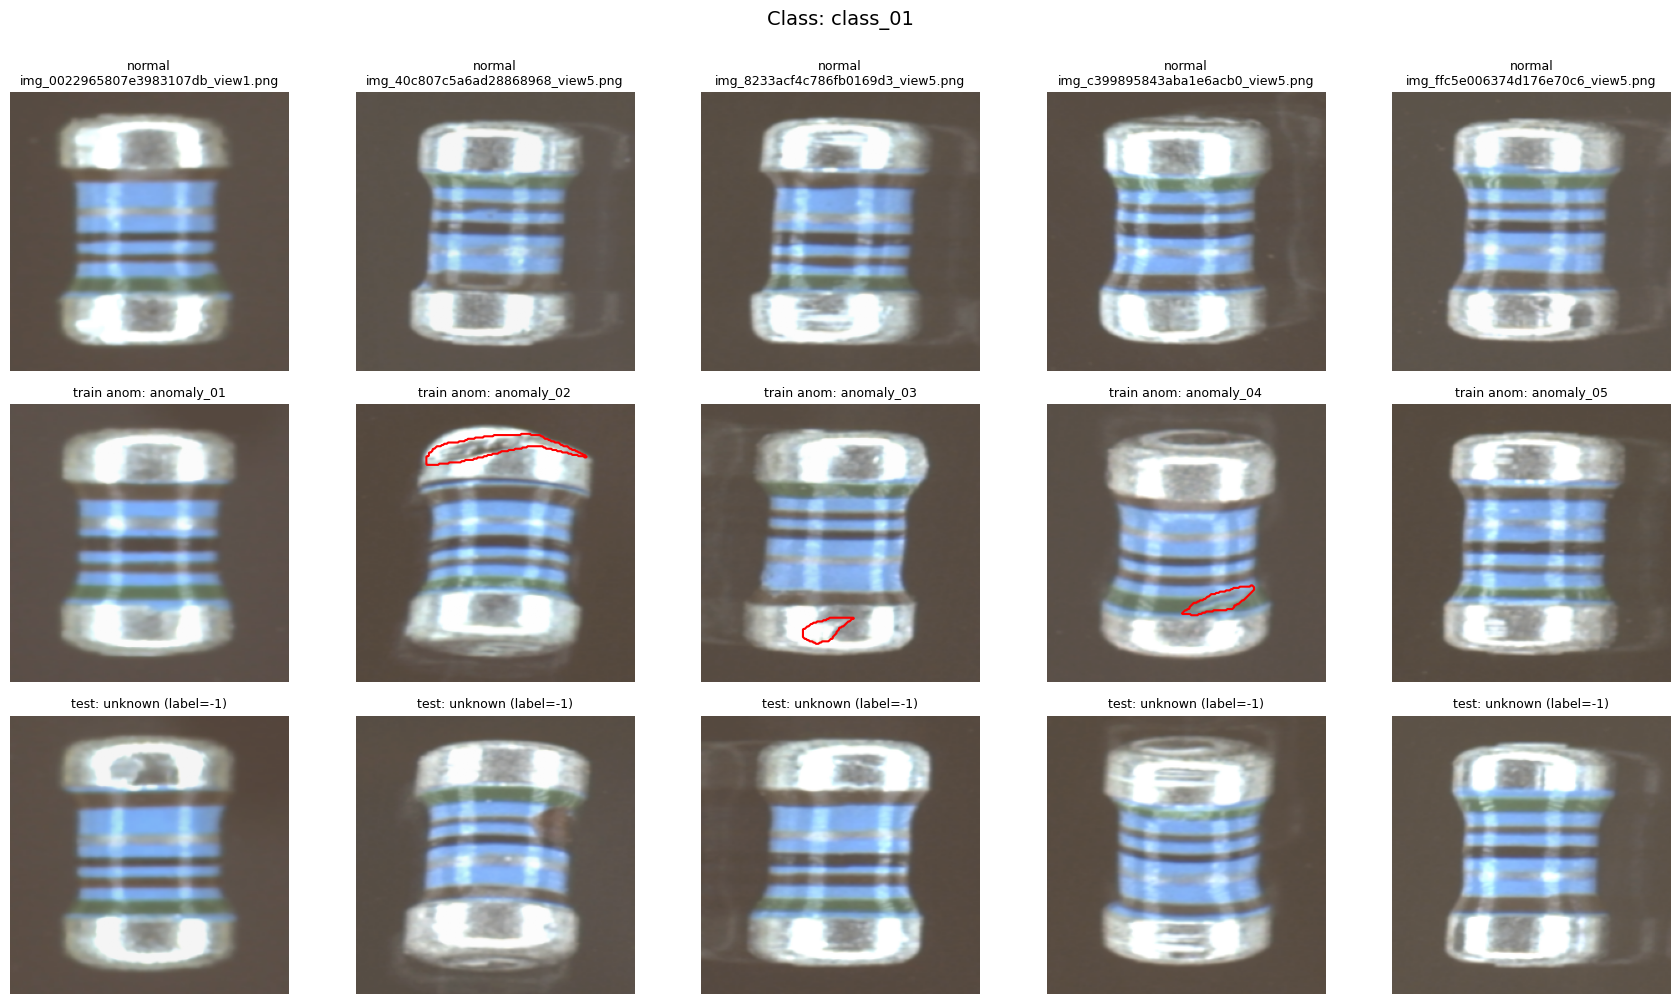

In [43]:
def tensor_to_numpy_image(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().permute(1, 2, 0).numpy()
    return np.clip(x, 0.0, 1.0)


def tensor_to_numpy_mask(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().squeeze().numpy()
    return x.astype(np.float32)


def show_class_overview(class_name, n=4):
    train_norm = ProjectDataset(DATASET_ROOT, class_name, "train_normal", IMAGE_SIZE)
    train_anom = ProjectDataset(DATASET_ROOT, class_name, "train_anomalous", IMAGE_SIZE)
    test_ds = ProjectDataset(DATASET_ROOT, class_name, "test", IMAGE_SIZE)

    fig, axes = plt.subplots(3, n, figsize=(3.5 * n, 10))
    for i, idx in enumerate(np.linspace(0, len(train_norm) - 1, n, dtype=int)):
        s = train_norm[int(idx)]
        axes[0, i].imshow(tensor_to_numpy_image(s["image"]))
        axes[0, i].set_title(f"normal\n{Path(s['path']).name}", fontsize=9)
        axes[0, i].axis("off")
    for i, idx in enumerate(np.linspace(0, len(train_anom) - 1, n, dtype=int)):
        s = train_anom[int(idx)]
        axes[1, i].imshow(tensor_to_numpy_image(s["image"]))
        m = tensor_to_numpy_mask(s["mask"])
        if m.sum() > 0:
            axes[1, i].contour(m, levels=[0.5], colors="red", linewidths=1.5)
        axes[1, i].set_title(f"train anom: {s['defect_type']}", fontsize=9)
        axes[1, i].axis("off")
    for i, idx in enumerate(np.linspace(0, len(test_ds) - 1, n, dtype=int)):
        s = test_ds[int(idx)]
        axes[2, i].imshow(tensor_to_numpy_image(s["image"]))
        m = tensor_to_numpy_mask(s["mask"])
        if m.sum() > 0:
            axes[2, i].contour(m, levels=[0.5], colors="red", linewidths=1.5)
        axes[2, i].set_title(f"test: {s['defect_type']} (label={s['label'].item()})", fontsize=9)
        axes[2, i].axis("off")
    plt.suptitle(f"Class: {class_name}", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()


classes = discover_classes(DATASET_ROOT) if DATASET_ROOT.exists() else []
if classes:
    DEMO_CLASS = classes[0]
    print(f"Showing class: {DEMO_CLASS}")
    show_class_overview(DEMO_CLASS, n=N_VIS_SAMPLES)
else:
    print("No classes discovered — fix DATASET_ROOT first.")

## 7. Metric utilities

Metric utilities are adapted from the lab notebook. For this project, the leaderboard evaluation metric is **Pixel-Level AP**.

In [44]:
def safe_metric(metric_fn, y_true, scores):
    y_true, scores = np.asarray(y_true), np.asarray(scores)
    if np.unique(y_true).size < 2:
        return float("nan")
    return float(metric_fn(y_true, scores))


def compute_metrics(results):
    """Compute image- and pixel-level metrics from a list of result dicts."""
    labeled = [r for r in results if r["label"] in (0, 1)]
    if not labeled:
        return {"image_auroc": float("nan"), "image_ap": float("nan"),
                "pixel_auroc": float("nan"), "pixel_ap": float("nan"),
                "n_labeled": 0}

    img_labels = np.array([r["label"] for r in labeled], dtype=np.int64)
    img_scores = np.array([r["score"] for r in labeled], dtype=np.float32)
    pix_masks = np.concatenate([r["mask"].reshape(-1) for r in labeled]).astype(np.uint8)
    pix_scores = np.concatenate([r["anomaly_map"].reshape(-1) for r in labeled]).astype(np.float32)
    return {
        "image_auroc": safe_metric(roc_auc_score, img_labels, img_scores),
        "image_ap":    safe_metric(average_precision_score, img_labels, img_scores),
        "pixel_auroc": safe_metric(roc_auc_score, pix_masks, pix_scores),
        "pixel_ap":    safe_metric(average_precision_score, pix_masks, pix_scores),
        "n_labeled":   len(labeled),
    }


def normalize_map(amap):
    amap = np.asarray(amap, dtype=np.float32)
    if amap.max() <= amap.min():
        return np.zeros_like(amap)
    return (amap - amap.min()) / (amap.max() - amap.min() + 1e-8)


def heatmap_overlay(image, amap, alpha=0.45):
    image = tensor_to_numpy_image(image) if isinstance(image, torch.Tensor) else image
    heat = plt.cm.jet(normalize_map(amap))[..., :3]
    return np.clip((1.0 - alpha) * image + alpha * heat, 0.0, 1.0)


def show_detection_results(results, n=5, title=None):
    if not results:
        return
    order = np.argsort([r["score"] for r in results])[::-1]
    chosen = order[: min(n, len(order))].tolist()
    fig, axes = plt.subplots(len(chosen), 4, figsize=(14, 3.3 * len(chosen)))
    if len(chosen) == 1:
        axes = np.expand_dims(axes, axis=0)
    if title:
        fig.suptitle(title, fontsize=14, y=1.02)
    for row, idx in enumerate(chosen):
        r = results[idx]
        axes[row, 0].imshow(r["image"])
        axes[row, 0].set_title(f"input  label={r['label']}  score={r['score']:.4f}")
        axes[row, 0].axis("off")
        axes[row, 1].imshow(heatmap_overlay(r["image"], r["anomaly_map"]))
        axes[row, 1].set_title("overlay"); axes[row, 1].axis("off")
        im = axes[row, 2].imshow(r["anomaly_map"], cmap="jet")
        axes[row, 2].set_title("anomaly map"); axes[row, 2].axis("off")
        plt.colorbar(im, ax=axes[row, 2], fraction=0.046, pad=0.04)
        axes[row, 3].imshow(r["mask"], cmap="gray")
        axes[row, 3].set_title("GT mask"); axes[row, 3].axis("off")
    plt.tight_layout()
    plt.show()


def _gaussian_kernel(window_size, sigma, channels, device, dtype):
    coords = torch.arange(window_size, device=device, dtype=dtype) - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2)); g = g / g.sum()
    k2 = torch.outer(g, g)
    return k2.expand(channels, 1, window_size, window_size).contiguous()


def gaussian_blur(x, sigma=4.0):
    if sigma is None or sigma <= 0:
        return x
    ks = int(max(3, 2 * round(4 * sigma) + 1))
    ks += 1 - (ks % 2)
    k = _gaussian_kernel(ks, float(sigma), x.shape[1], x.device, x.dtype)
    pad = ks // 2
    x = F.pad(x, (pad, pad, pad, pad), mode="reflect")
    return F.conv2d(x, k, groups=x.shape[1])

## 8. PatchCore

PatchCore is a **feature-based** detector that works on patches encoded in the latent space.

### How it works
1. **Builds a memory bank.** PatchCore passes every training (normal) image through a
   pretrained backbone (in this case, a DINOv2-Base model), extracts patch-level feature vectors 
   from a couple of intermediate layers, and stores them in a "memory bank" of normal patches.
2. **Scores test images.** For every patch in the test image, PatchCore computes its
   distance to its nearest neighbour in the memory bank. Patches that don't
   look like *any* normal patch get a high distance, hence a high anomaly
   score.
3. **Generates the heatmaps.** The per-patch distances form a low-resolution map; they are
   then upsamples to image resolution, smoothed, and the per-image score is just
   the max value in the smoothed map.

### Implementation details
- **Intermediate layers, not the final one.** The backbone's final layer is too
  semantic ("dog vs. cat") and loses spatial precision. Layers 2 and 3 keep
  enough spatial structure to localize defects.
- **Local averaging.** Each patch vector is averaged with its small neighbourhood, capturing 
  local context instead of a single set of features.
- **Coreset subsampling of the memory bank**. The full bank can be hundreds of
  thousands of patches; only a subset is kept via a *greedy k-center* selection that
  preserves the boundary of the normal feature distribution (which is exactly
  what nearest-neighbour distance cares about for anomalous samples).
- **Single-class memory bank.** A different PatchCore instance is fit for each class in the dataset,
  so that each memory bank contains only patches for one single class, otherwise the definition of
  normality would be too lax.

In [45]:
from transformers import AutoModel 

class DinoV2FeatureExtractor(nn.Module):
     def __init__(self, model_name="facebook/dinov2-base"):
         super().__init__()
         self.backbone_name = model_name
         self.model = AutoModel.from_pretrained(model_name).to(DEVICE).eval()
         for p in self.model.parameters():
             p.requires_grad_(False)
         self.register_buffer("mean", torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1), persistent=False)
         self.register_buffer("std",  torch.tensor(IMAGENET_STD).view(1, 3, 1, 1),  persistent=False)
         self.patch_size = self.model.config.patch_size  # typically 14

     def forward(self, x):
         # DINOv2 expects sizes divisible by patch_size; resize accordingly.
         x = (x - self.mean) / self.std
         B, _, H, W = x.shape
         out = self.model(pixel_values=x, output_hidden_states=True)
         hidden = out.hidden_states  # tuple of (B, 1+Np, C)
         h = H // self.patch_size; w = W // self.patch_size
         feats = []
         for layer_idx in (-4, -1):
             tokens = hidden[layer_idx][:, 1:]
             feats.append(tokens.transpose(1, 2).reshape(B, -1, h, w))
         return feats


In [ ]:
# ============================================================================
#  PatchCore — annotated implementation
# ============================================================================
# Imagenet normalization stats. The pretrained CNN (WideResNet50, ResNet18)
# was trained on ImageNet, so inputs must be normalized with these stats.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# We try a heavy backbone first; if it doesn't fit in GPU memory we fall back
# to a lighter one. All entries here must be valid timm model names.
PATCHCORE_BACKBONE_CANDIDATES = ["wide_resnet50_2", "resnet18"]

# Which intermediate layers to use as features. (2, 3) corresponds to ResNet's
# layer2 and layer3 — middle of the network, which keeps spatial structure.
PATCHCORE_OUT_INDICES = (2, 3)

# Local-averaging kernel: each patch feature vector gets averaged with a 3x3
# neighbourhood. Larger -> more context but coarser localization.
PATCHCORE_PATCHSIZE = 3

# Coreset = subsample of the memory bank. Keep this fraction of all patches.
# 0.01 = 1%. Larger values cost more memory but can improve pixel AP.
PATCHCORE_CORESET_FRACTION = 0.05

# Reservoir-sampled candidate pool size. The greedy coreset is run on this
# pool, NOT on the full set of patches (that would be too slow / use too much
# RAM). The pool is sampled uniformly at random in one streaming pass.
PATCHCORE_CANDIDATE_POOL_SIZE = 6000

# Memory-bank chunk size for nearest-neighbour search at test time. Smaller
# chunks use less memory, larger chunks are faster.
PATCHCORE_BANK_CHUNK_SIZE = 2048

# Sigma of the Gaussian we apply to the upsampled anomaly map. Smooths out
# spurious peaks; comparable to the smoothing in the original PatchCore paper.
ANOMALY_MAP_SIGMA = 4.0


def greedy_coreset(points, k, seed=SEED):
    """Greedy k-center selection.

    Picks `k` points one at a time, each time choosing the point that is
    *farthest* from anything already selected. This biases the selection
    toward the boundary of the point cloud — exactly what we want for
    nearest-neighbour anomaly detection: anomalies sit outside the normal
    cloud, so we want bank points on its edge to detect them quickly.

    Complexity is O(n*k), which is the bottleneck — that's why we sample down
    to `candidate_pool` first and run the coreset on the smaller pool.
    """
    points = points.float()
    n = points.shape[0]
    if n <= k:
        return torch.arange(n, dtype=torch.long)
    g = torch.Generator(device=points.device); g.manual_seed(seed)
    # First point at random.
    first = int(torch.randint(0, n, (1,), generator=g, device=points.device).item())
    selected = [first]
    # min_dist[i] = distance from points[i] to its nearest selected point.
    min_dist = torch.cdist(points, points[first:first + 1]).squeeze(1)
    for _ in tqdm(range(1, k), desc="Greedy coreset", leave=False):
        # Pick the most "underserved" point — farthest from anything selected.
        nxt = int(torch.argmax(min_dist).item())
        selected.append(nxt)
        # Update min_dist: every point's distance to its nearest selected point
        # can only decrease (or stay the same) when we add a new selected point.
        d = torch.cdist(points, points[nxt:nxt + 1]).squeeze(1)
        min_dist = torch.minimum(min_dist, d)
    return torch.tensor(selected, dtype=torch.long)


def knn_search(query, bank, chunk=2048):
    """For each query vector, find its nearest neighbour in `bank`.

    We process the bank in chunks because the full pairwise distance matrix
    `cdist(query, bank)` would be query_size * bank_size floats — usually too
    big to materialize.
    """
    query, bank = query.float(), bank.float()
    best_d = torch.full((query.shape[0],), float("inf"), dtype=torch.float32)
    best_i = torch.full((query.shape[0],), -1, dtype=torch.long)
    for s in range(0, bank.shape[0], chunk):
        chunk_bank = bank[s:s + chunk]
        # cdist returns a (query_size, chunk_size) distance matrix.
        d = torch.cdist(query, chunk_bank)
        v, i = d.min(dim=1)               # nearest within this chunk
        upd = v < best_d                  # is the chunk's nearest better than what we had?
        best_d[upd] = v[upd]
        best_i[upd] = i[upd] + s          # store the global bank index
    return best_d, best_i


class PatchCore:
    def __init__(self, backbones=PATCHCORE_BACKBONE_CANDIDATES, out_indices=PATCHCORE_OUT_INDICES,
                 patchsize=PATCHCORE_PATCHSIZE, coreset_fraction=PATCHCORE_CORESET_FRACTION,
                 candidate_pool=PATCHCORE_CANDIDATE_POOL_SIZE, bank_chunk=PATCHCORE_BANK_CHUNK_SIZE,
                 sigma=ANOMALY_MAP_SIGMA):
        self.feat = DinoV2FeatureExtractor().to(DEVICE).eval()
        self.backbone_name = self.feat.backbone_name
        self.patchsize = patchsize
        self.coreset_fraction = coreset_fraction
        self.candidate_pool = candidate_pool
        self.bank_chunk = bank_chunk
        self.sigma = sigma
        self.memory_bank = None    # Filled by .fit(). Shape: (n_coreset, embedding_dim).

    @torch.no_grad()
    def _embed(self, images):
        """Turn a batch of images into a grid of patch feature vectors.

        Output shape: (B, H, W, C) where (H, W) is the spatial grid of the
        SHALLOWER feature map (highest-resolution). All deeper feature maps
        are upsampled to that resolution, then concatenated along the
        channel axis.

        So each spatial location (h, w) holds a vector that combines features
        from all selected layers — a multi-scale patch descriptor.
        """
        images = images.to(DEVICE, non_blocking=True)
        feats = self.feat(images)                  # list of (B, C_l, H_l, W_l)
        target_hw = feats[0].shape[-2:]            # finest grid (shallowest layer)
        out = []
        for f in feats:
            # Local averaging: replace each cell's feature by the mean of its
            # patchsize x patchsize neighbourhood. This adds local context.
            f = F.avg_pool2d(f, kernel_size=self.patchsize, stride=1, padding=self.patchsize // 2)
            # Resize deeper feature maps to match the finest grid so we can concat.
            if f.shape[-2:] != target_hw:
                f = F.interpolate(f, size=target_hw, mode="bilinear", align_corners=False)
            out.append(f)
        # Concatenate channel-wise: the final embedding has dim sum(C_l for l in layers).
        emb = torch.cat(out, dim=1)
        # Reshape to (B, H, W, C) so each spatial location is one row.
        return emb.permute(0, 2, 3, 1).contiguous()

    @torch.no_grad()
    def fit(self, loader):
        """Build the memory bank using streaming reservoir sampling.

        Why reservoir sampling? A naive implementation would extract every
        patch from every training image, stack them all in memory, then
        randomly sample `candidate_pool` of them and run the greedy coreset.
        For a class with 200 images at 224x224 with feature grid 14x14, that's
        200 * 14 * 14 = ~40k patches per class, times the embedding dim
        (~1500 for WideResNet50 layers 2+3) — many GB of RAM.

        Reservoir sampling (Algorithm R variant) keeps a fixed-size pool and
        does the sampling in a single streaming pass: when a new patch arrives,
        we accept it with probability `pool_size / n_seen` and replace a random
        existing entry. The result is mathematically equivalent to picking a
        uniform random sample of size `pool_size` from the full stream, but
        we never materialize the full stream.
        """
        cand_n = int(self.candidate_pool)
        cand = None             # The reservoir; allocated lazily once we know the dim.
        n_seen = 0              # How many patches we've processed so far.
        rng = np.random.default_rng(SEED)

        for batch in tqdm(loader, desc="PatchCore: extracting features"):
            emb = self._embed(batch["image"])
            # (B*H*W, C) — flat list of patch vectors for this batch.
            flat = emb.reshape(-1, emb.shape[-1]).detach().cpu().numpy().astype(np.float32)

            if cand is None:
                cand = np.empty((cand_n, flat.shape[1]), dtype=np.float32)

            # ---- Phase 1: fill the reservoir until it holds cand_n items ----
            if n_seen < cand_n:
                take = min(cand_n - n_seen, flat.shape[0])
                cand[n_seen:n_seen + take] = flat[:take]
                n_seen += take
                flat = flat[take:]   # remaining patches go through phase 2

            # ---- Phase 2: replace existing items with decaying probability ----
            # For each remaining patch, accept with probability cand_n/n_seen.
            # The acceptance probability decreases as n_seen grows, which is
            # exactly what makes the final reservoir uniform over the stream.
            if flat.size:
                m = flat.shape[0]
                # Vectorized: probability per item, accounting for the running
                # count being incremented one at a time.
                p = cand_n / (n_seen + np.arange(1, m + 1))
                keep = rng.random(m) < p
                if np.any(keep):
                    # Each accepted patch evicts a random reservoir entry.
                    replace = rng.integers(0, cand_n, size=keep.sum())
                    cand[replace] = flat[keep]
                n_seen += m

        # ---- Run greedy coreset on the (small) reservoir ----
        cand = torch.from_numpy(cand)
        k = max(1, int(round(n_seen * self.coreset_fraction)))
        k = min(k, cand.shape[0])    # never select more than the reservoir holds
        sel = greedy_coreset(cand, k=k, seed=SEED)
        self.memory_bank = cand[sel].contiguous()
        print(f"  bank: {n_seen:,} patches -> coreset {self.memory_bank.shape[0]:,}")
        return self

    @torch.no_grad()
    def predict(self, loader):
        """For each test image, return the anomaly map and image-level score."""
        if self.memory_bank is None:
            raise RuntimeError("Call fit() first.")
        bank = self.memory_bank
        results = []
        for batch in tqdm(loader, desc="PatchCore: scoring"):
            images = batch["image"]
            emb = self._embed(images)               # (B, H, W, C)
            b, h, w, c = emb.shape
            # Flatten to (B*H*W, C) — one row per spatial patch.
            flat = emb.reshape(-1, c).detach().cpu().float()
            # For each patch, distance to its nearest normal-bank neighbour.
            dists, _ = knn_search(flat, bank, chunk=self.bank_chunk)
            # Reshape back to (B, H, W) — the low-res anomaly map.
            score_small = dists.view(b, h, w)
            # Upsample to full image resolution.
            amap = F.interpolate(score_small.unsqueeze(1), size=images.shape[-2:],
                                 mode="bilinear", align_corners=False)
            # Smooth out spurious single-patch peaks.
            amap = gaussian_blur(amap, sigma=self.sigma)
            # Image-level score = max anomaly value (a single very anomalous
            # patch is enough to call the whole image anomalous).
            img_scores = amap.flatten(1).amax(dim=1)
            for i in range(b):
                results.append({
                    "image": tensor_to_numpy_image(images[i]),
                    "anomaly_map": amap[i, 0].detach().cpu().numpy().astype(np.float32),
                    "mask": tensor_to_numpy_mask(batch["mask"][i]),
                    "label": int(batch["label"][i].item()),
                    "score": float(img_scores[i].item()),
                    "defect_type": batch["defect_type"][i],
                    "path": batch["path"][i],
                })
        return results

In [47]:
def run_patchcore_for_class(class_name, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                            verbose=True):
    """Submission-mode run: fit PatchCore on ALL train normals, predict on test.

    Use this for the final submission, AFTER you've validated hyperparameters
    using `validate_patchcore_for_class` (defined below). The metrics returned
    will all be NaN because the test set has no GT — that's expected.
    """
    train_ds = ProjectDataset(DATASET_ROOT, class_name, "train_normal", image_size)
    test_ds  = ProjectDataset(DATASET_ROOT, class_name, "test", image_size)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

    if verbose:
        print(f"[{class_name}] train_normal={len(train_ds)}  test={len(test_ds)}")

    pc = PatchCore()
    pc.fit(train_loader)
    results = pc.predict(test_loader)
    metrics = compute_metrics(results)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    del pc
    return results, metrics

## 9. Validation to estimate performance before submission

Since the test set has no GT, we build a **validation set** from training data:

- **Held-out normals**: take `VAL_RATIO` (default 15%) of `train/good/`, set
  them aside. Their label is 0 and their mask is all zeros.
- **Few-shot anomalies**: the 25 anomalous training images (5 types × 5 each)
  with their pixel masks. Label is 1.

The two sets are concatenated into one validation dataset. We then fit
PatchCore on the **remaining** 85% of normals only and predict on validation.

### Considerations
- The validation set is VERY small. Pixel AP on it
  will be much noisier than on the full test set and very easy to overfit.
- If the test set contains anomaly types **not** in the train folder, the
  validation pixel AP will overestimate test pixel AP.

In [48]:
from torch.utils.data import ConcatDataset


def validate_patchcore_for_class(class_name, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                                 val_ratio=VAL_RATIO, verbose=True):
    """Validation-mode run: hold out a slice of normals + use the few-shot
    anomalies as the validation set. Returns (val_results, val_metrics).

    Steps:
      1. Load train/good/ -> split into (train_kept, val_normal) via val_ratio.
      2. Load train_anomalous/ (the 25 masked anomalies).
      3. Validation set = val_normal + train_anomalous (both have GT masks).
      4. Fit PatchCore on train_kept ONLY.
      5. Predict on validation set; compute pixel & image AP / AUROC.
    """
    train_normal_full = ProjectDataset(DATASET_ROOT, class_name, "train_normal", image_size)
    train_anom = ProjectDataset(DATASET_ROOT, class_name, "train_anomalous", image_size)

    if len(train_anom) == 0:
        print(f"[{class_name}] no anomalous training samples — skipping validation.")
        return None, None

    train_kept, val_normal = split_train_val(train_normal_full, val_ratio=val_ratio, seed=SEED)
    val_dataset = ConcatDataset([val_normal, train_anom])

    if verbose:
        print(f"[{class_name}] fit on {len(train_kept)} normals; "
              f"validate on {len(val_normal)} held-out normals + {len(train_anom)} anomalies")

    train_loader = DataLoader(train_kept, batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

    pc = PatchCore()
    pc.fit(train_loader)
    val_results = pc.predict(val_loader)
    val_metrics = compute_metrics(val_results)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    del pc
    return val_results, val_metrics


### 9.1 Validate on all 8 classes

In [49]:
def validate_all_classes(class_list, val_ratio=VAL_RATIO, verbose=True):
    """Run validate_patchcore_for_class on every class. Return summary df + dict of results."""
    rows = []
    all_val_results = {}
    for cn in class_list:
        print(f"\n========== {cn} (validation) ==========")
        val_results, val_metrics = validate_patchcore_for_class(cn, val_ratio=val_ratio, verbose=verbose)
        if val_metrics is not None:
            rows.append({"class": cn, **val_metrics})
            all_val_results[cn] = val_results
    df = pd.DataFrame(rows)
    if "pixel_ap" in df.columns and df["pixel_ap"].notna().any():
        avg_pix_ap = df["pixel_ap"].mean()
        avg_img_ap = df["image_ap"].mean() if "image_ap" in df.columns else float("nan")
        print(f"\n>>> VALIDATION  mean pixel AP: {avg_pix_ap:.4f}  |  mean image AP: {avg_img_ap:.4f}")
        print(f"    (over {df['pixel_ap'].notna().sum()} classes)")
    return df, all_val_results


# Run validation across all discovered classes. To iterate faster while
# debugging, restrict to a subset (e.g. classes[:2]).
if classes:
    val_summary_df, all_val_results = validate_all_classes(classes)
    display(val_summary_df.round(4))


========== class_01 (validation) ==========
[class_01] fit on 2210 normals; validate on 390 held-out normals + 25 anomalies


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

PatchCore: extracting features:   0%|          | 0/139 [00:00<?, ?it/s]

  bank: 565,760 patches -> coreset 6,000


PatchCore: scoring:   0%|          | 0/26 [00:00<?, ?it/s]

...

PatchCore: extracting features:   0%|          | 0/109 [00:00<?, ?it/s]

  bank: 444,928 patches -> coreset 6,000


PatchCore: scoring:   0%|          | 0/22 [00:00<?, ?it/s]


>>> VALIDATION  mean pixel AP: 0.3982  |  mean image AP: 0.4551
    (over 8 classes)


,class,image_auroc,image_ap,pixel_auroc,pixel_ap,n_labeled
0,class_01,0.7329,0.3983,0.9822,0.6311,415
1,class_02,0.8325,0.6593,0.9956,0.5960,350
2,class_03,0.7520,0.2269,0.9680,0.0286,398
3,class_04,0.8184,0.3269,0.9529,0.1442,413
4,class_05,0.8069,0.3799,0.9872,0.3423,426
5,class_06,0.8971,0.5438,0.9693,0.6118,385
6,class_07,0.7962,0.2791,0.8639,0.1077,357
7,class_08,0.9192,0.8269,0.9907,0.7242,342


## 10. Generating the PatchCore submission

The following cells refit PatchCore instances on **all** train normals of one class 
at a time (no held-out set this time) and predict the test images.

Pixel/image AP printed here will be **NaN** because the test set has no GT. The
performance estimates are obtained from validation in the previous cells.

In [63]:
def evaluate_all_classes(method_fn, class_list, save_predictions_dir=None):
    """Run `method_fn` on every class and aggregate results.

    method_fn(class_name) must return (results, metrics).

    If save_predictions_dir is set, dumps each test image's anomaly map as a
    .npy file (we don't actually need this for submission since the friend's
    code below builds the CSV directly from `all_results`, but it can be useful
    for debugging / re-running the encoding without re-running the whole fit).
    """
    rows = []
    all_results = {}
    for cn in class_list:
        print(f"\n========== {cn} ==========")
        results, metrics = method_fn(cn)
        rows.append({"class": cn, **metrics})
        all_results[cn] = results
        if save_predictions_dir is not None:
            outdir = Path(save_predictions_dir) / cn
            outdir.mkdir(parents=True, exist_ok=True)
            for r in results:
                stem = Path(r["path"]).stem
                np.save(outdir / f"{stem}_amap.npy", r["anomaly_map"])
    df = pd.DataFrame(rows)
    # On the test set this branch is skipped (all NaN), but it kicks in if you
    # ever run this on a labeled split.
    if "pixel_ap" in df.columns and df["pixel_ap"].notna().any():
        avg_pix_ap = df["pixel_ap"].mean()
        print(f"\n>>> Average pixel AP over {df['pixel_ap'].notna().sum()} classes: {avg_pix_ap:.4f}")
    return df, all_results


# Final submission-mode run on all 8 classes.
if classes:
    SUBSET = classes  # e.g. classes[:2] to test on the first two
    summary_df, all_results = evaluate_all_classes(
        run_patchcore_for_class, SUBSET,
        save_predictions_dir=None,
    )
    display(summary_df.round(4))


========== class_01 ==========
[class_01] train_normal=2600  test=465


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

PatchCore: extracting features:   0%|          | 0/163 [00:00<?, ?it/s]

  bank: 665,600 patches -> coreset 6,000


PatchCore: scoring:   0%|          | 0/30 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

PatchCore: extracting features:   0%|          | 0/128 [00:00<?, ?it/s]

  bank: 523,520 patches -> coreset 6,000


PatchCore: scoring:   0%|          | 0/60 [00:00<?, ?it/s]

,class,image_auroc,image_ap,pixel_auroc,pixel_ap,n_labeled
0,class_01,NaN,NaN,NaN,NaN,0
1,class_02,NaN,NaN,NaN,NaN,0
2,class_03,NaN,NaN,NaN,NaN,0
3,class_04,NaN,NaN,NaN,NaN,0
4,class_05,NaN,NaN,NaN,NaN,0
5,class_06,NaN,NaN,NaN,NaN,0
6,class_07,NaN,NaN,NaN,NaN,0
7,class_08,NaN,NaN,NaN,NaN,0


### Saving predictions for submission

In [ ]:
# ============================================================================
#  Build the submission CSV
# ============================================================================
# The competition wants a CSV with two columns: ID, Label
#   - ID:    a string identifying each test image
#   - Label: the anomaly map encoded as a "q8rle" string

import csv
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp"}


def float_matrix_to_q8rle(x):
    q = np.clip(np.rint(np.asarray(x, dtype=np.float32) * 255), 0, 255).astype(np.uint8)
    h, w = q.shape
    flat = q.T.reshape(-1)
    if flat.size == 0:
        return f"q8rle {h} {w}"
    cuts = np.flatnonzero(flat[1:] != flat[:-1]) + 1
    starts = np.r_[0, cuts]
    ends = np.r_[cuts, flat.size]
    parts = ["q8rle", str(h), str(w)]
    for v, n in zip(flat[starts], ends - starts):
        parts += [str(int(v)), str(int(n))]
    return " ".join(parts)


def write_submission_csv(rows, csv_path):
    path = Path(csv_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["ID", "Label"])
        w.writerows(rows)


def iter_test_images(dataset_dir):
    dataset_dir = Path(dataset_dir)
    for class_dir in sorted(dataset_dir.glob("class_*")):
        test_dir = class_dir / "test"
        for path in sorted(test_dir.rglob("*")):
            if path.suffix.lower() in IMAGE_EXTS:
                yield path.relative_to(dataset_dir).as_posix(), path


def normalize_map(amap):
    amap = np.asarray(amap, dtype=np.float32)
    amin, amax = float(amap.min()), float(amap.max())
    if amax <= amin:
        return np.zeros_like(amap)
    return (amap - amin) / (amax - amin + 1e-8)

def global_normalize_map(amap, gmin, gmax):
    """Normalizes an anomaly map using global dataset bounds."""
    amap = np.asarray(amap, dtype=np.float32)
    if gmax <= gmin:
        return np.zeros_like(amap)
    return (amap - gmin) / (gmax - gmin + 1e-8)


def resize_map_to(amap, target_hw):
    """Bilinearly resize a 2D float anomaly map to target (H, W)."""
    if amap.shape == tuple(target_hw):
        return amap
    t = torch.from_numpy(amap.astype(np.float32))[None, None]   # (1,1,H,W)
    t = F.interpolate(t, size=tuple(target_hw), mode="bilinear", align_corners=False)
    return t.squeeze().numpy()


def get_original_hw(image_path):
    """(height, width) of the original image on disk — doesn't load pixels."""
    with Image.open(image_path) as im:
        w, h = im.size       # PIL returns (width, height)
    return h, w


DATASET_DIR = DATASET_ROOT

# Lookup: relative-path-string -> anomaly map at IMAGE_SIZE x IMAGE_SIZE
path_to_map = {}
for cn, results in all_results.items():
    for r in results:
        rel = Path(r["path"]).relative_to(DATASET_DIR).as_posix()
        path_to_map[rel] = r["anomaly_map"]

ids = []
labels = []

print("Step 1: Computing global min/max across all test predictions...")
global_min = float('inf')
global_max = float('-inf')

# Pass 1: Find the global minimum and maximum anomaly scores
for raw_amap in path_to_map.values():
    amap_np = np.asarray(raw_amap, dtype=np.float32)
    global_min = min(global_min, float(amap_np.min()))
    global_max = max(global_max, float(amap_np.max()))

print(f"Global Min: {global_min:.4f}, Global Max: {global_max:.4f}")
print("Step 2: Resizing, normalizing, and generating RLE submissions...")

# Pass 2: Resize, normalize globally, and encode
for img_id, img_path in iter_test_images(DATASET_DIR):
    amap = path_to_map[img_id]

    # Resize the (224, 224) PatchCore output back to original image size
    orig_hw = get_original_hw(img_path)
    amap = resize_map_to(amap, orig_hw)

    # Normalize using the GLOBAL bounds, not per-image bounds!
    amap = global_normalize_map(amap, global_min, global_max)
    
    ids.append(img_id[14:-4])
    labels.append(float_matrix_to_q8rle(amap))

print("Done building submission.")

SUBMISSION_PATH = Path("submission_patchcore.csv")
write_submission_csv(list(zip(ids, labels)), SUBMISSION_PATH)
print(f"Wrote {len(ids)} rows to {SUBMISSION_PATH}")

Step 1: Computing global min/max across all test predictions...
Global Min: 4.4428, Global Max: 51.6586
Step 2: Resizing, normalizing, and generating RLE submissions...
Done building submission.
Wrote 5910 rows to submission_patchcore.csv


In [71]:
!zip -j submission_patchcore.zip submission_patchcore.csv

updating: submission_patchcore.csv (deflated 86%)


In [72]:
from IPython.display import FileLink
FileLink('submission_patchcore.zip')

/kaggle/working/submission_patchcore.zip